## 사전에 설정하기
1. API_key 가져오기 (.env파일에 따로 보관해서 사용함)
2. 캐시 설정하기
3. langsmith로 추적 설정하기 (본 파일에서는 생략함)

In [1]:
# 나만의 API_KEY 가져오기
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# 캐시 설정하기
# SQLiteCache를 설정하였음

from langchain_core.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

# DB를 저장할 공간과 이름만 설정해주면 알아서 폴더도 생성
set_llm_cache(SQLiteCache(database_path='../cache/langgraph_basic.db'))

## 용어들 정리
1. TypedDict: Dictionary와 같으나 타입까지 지정해주고 상속해서 사용하는 형식
2. Annotated: List로 받으며 설명을 넣거나 함수를 실행시킬 수 있음.
3. add_messages: 들어오는 값들을 추가해주고 ai 혹은 사용자가 주고 받은 메세지를 기록하기 용

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

# TypedDict 예시
class A(TypedDict):
    name: str

# Annotated 예시
class A(TypedDict):
    name: Annotated[str, "someone's name"]

# add_messages 예시
class A(TypedDict):
    name: Annotated[str, "someone's name"]
    messages: Annotated[list, add_messages]

## 간단한 챗봇 구축
langgraph는 node+edge+state를 합친 framework인데
langgraph에서는 "노드"라고 표현한 어떠한 역할을 하는 부분들이 있고
그 노드들을 이어주는 "엣지"가 있는데 이렇게 지나다닐때 "상태"라고 특정 클래스에 값들을 저장해서 노드와 엣지에서 사용한다.

여기선 간단한 상태 정의, 노드 정의, 엣지 정의, 그리고 모든것을 합친 그래프 생성,
그리고 간단 사용까지 해볼 것이다.

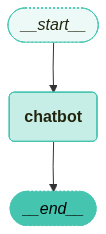

In [33]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_teddynote.graphs import visualize_graph

# 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 챗봇 정의
# ai가 대답을 하는 함수를 만들어 놓을건데 "상태"를 받도록 할것임.
# 먼저 llm 생성후 chatbot이라는 함수 만들기
llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0,
    max_tokens=256,
)

def chatbot(state):
    # 챗봇 호출
    response = llm.invoke(state['messages'])
    return {'messages': [response]}

# 위에서 받은 state는 상태, 즉 맨위에서 만든 State를 받을것이며
# 똑같이 state에 넣어주듯이 return 하는데 list로 정의 했기에 list로 반환

# 그래프 정의
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node('chatbot', chatbot)
# chatbot이 함수로 정의되어 있으면 graph_builder.add_node(chatbot) 이렇게 써도됨

# 엣지 생성
# 1. 시작 -> chatbot
# 2. chatbot -> 끝
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('chatbot', END)

# 그래프 생성
graph = graph_builder.compile()

# 시각화
visualize_graph(graph)

In [5]:

# 실제 사용
question = '대전 성심당에서 가장 인기있는 빵 10개 추천해줘'
for event in graph.stream({'messages': [('user', question)]}):
    for value in event.values():
        print("Answer\n", value['messages'][-1].content)

Answer
 대전 성심당은 다양한 맛있는 빵으로 유명한 제과점입니다. 여기에서 인기 있는 빵 10가지를 추천해 드릴게요:

1. **소보루빵** - 고소한 소보루가 얹혀진 부드러운 빵.
2. **카스테라** - 촉촉하고 부드러운 식감의 전통적인 카스테라.
3. **크림빵** - 달콤한 크림이 가득 들어 있는 빵.
4. **단팥빵** - 달콤한 단팥이 들어간 전통적인 빵.
5. **치즈빵** - 고소한 치즈가 들어간 빵으로, 짭짤한 맛이 일품.
6. **바게트** - 바삭한 겉과 부드러운 속이 조화를 이루는 프랑스식 빵.
7. **모카빵** - 커피 맛이 나는 부드러운 빵.
8. **호두빵** - 고소한 호두가 들어간 빵으로, 영양가가 높음.
9. **버터롤** -


## Tool사용
앞에선 llm만을 이용해서 사용했는데 실제 뉴스 검색 툴이라던지 다른 API를 써서 더 정확한 정보를 얻을 수 있고 여기서 해볼 것이다.

In [6]:
# 위에서 정의한 부분은 그대로 사용하고 tool만 추가해서 사용할 것임.
from langchain_teddynote.tools.tavily import TavilySearch

# tool 정의
tool = TavilySearch(max_results=3)

In [7]:
import json
from langchain_core.messages import ToolMessage

# 툴을 그래프에 그대로 넣을 순 없고 tool mesage형식으로 뽑아내야 하는데
# 그부분을 직접 간단히 구현할 것임. (추후엔 라이브러리에서 가져올것임.)

class BasicToolNode:
    """Run this tool when requested after the last AIMessage"""
    def __init__(self, tools: list):
        self.tools_list = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        # 마지막 ai message를 가지고 tool을 이용할 것임.
        if messages := inputs.get('messages', []):
            message = messages[-1]
        # 메세지가 없다고 나오면 오류 발생시키고
        else:
            raise ValueError("No Message found in inputs")
        
        # 이제 tool의 출력을 받을것임.
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_list[tool_call['name']].invoke(tool_call['args'])
            outputs.append(
                ToolMessage(
                    content=json.dumps(
                        tool_result, ensure_ascii=False
                    ),
                    tool_call_id=tool_call['id'],
                    name=tool_call['name']
                )
            )
        return {'messages': outputs}
    
    

In [34]:
# 먼저 llm이 툴을 가지고 잇구나 라는걸 알아야함.
tools = [tool] # 현재는 한개
llm_with_tools = llm.bind_tools(tools)

# 상태부터 재정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 챗봇도 재정의
def chatbot(state):
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

# 그래프 정의
graph_builder = StateGraph(State)

# chatbot node 정의
graph_builder.add_node(chatbot)
graph_builder.add_edge(START, 'chatbot')

# tool node를 만들어서 graph에 추가하기
tool_node = BasicToolNode(tools)
graph_builder.add_node('tools', tool_node)

In [35]:
# 라우터, 조건이 달린 엣지에서 (조건부엣지) 어디로 갈지 정해주는 함수를 지정할 것임
def route_tools(state):
    if messages := state.get('messages', []):
        message = messages[-1]
    else:
        raise ValueError("No Message found in state")
    if message.tool_calls:
        return 'use tool'
    return 'no tool'

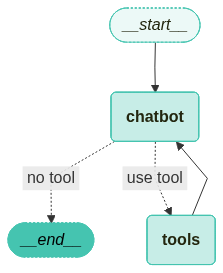

In [36]:
# 그래프 최종 생성
# tool node를 조건부로 가거나 안가도록 할것임.

# 조건부 엣지 생성
# chatbot 노드에서 tool을 쓰거나 안쓰도록 정하고 실제 그래프에서 매핑해준다.
graph_builder.add_conditional_edges(
    source='chatbot',
    path=route_tools,
    path_map={
        'use tool': 'tools',
        'no tool': END
    }

)
graph_builder.add_edge('tools', 'chatbot')

graph_with_tools = graph_builder.compile()

# 실제 시각화로 어떻게 변했는지 보자
visualize_graph(graph_with_tools)


STEP: chatbot

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 22
            prompt_tokens: 97
            total_tokens: 119
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 0}
        model_provider: "openai"
        model_name: "gpt-4o-mini-2024-07-18"
        system_fingerprint: "fp_b541469465"
        id: "chatcmpl-Dfmb4t6gMmfvv9QN1uIn9tTvMnvQa"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--019e2bc2-7da1-7f80-a54d-d38c7e5c4a36-0"
    tool_calls:
        index [0]
            name: "tavily_web_search"
            args: {"query": "만기퇴소 YouTube"}
            id: "call_MbeqKozZ9wXf4JKGzZcDYPxI"
            type: "tool_call"
    invalid_tool_ca
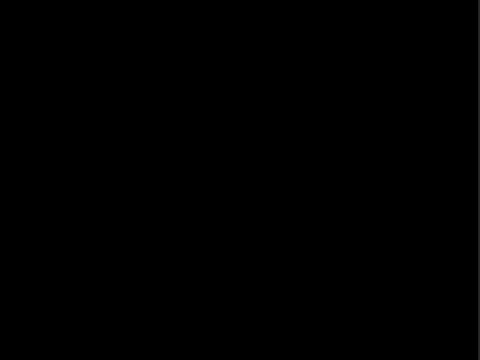

In [ ]:
# 검색을 요하는 예시
# tokens가 얼마나 쓰였는지 등등을 나타내도록 사용해볼것임.
from langchain_teddynote.messages import display_message_tree
question = '만기퇴소 YouTube'

for event in graph_with_tools.stream({'messages': [('user', question)]}):
    for key, value in event.items():
        print(f"\n==========\nSTEP: {key}\n============\n")
        display_message_tree(value['messages'][-1])

In [37]:
# tool이 없을때 사용하면 
for event in graph.stream({'messages': [('user', question)]}):
    for key, value in event.items():
        print(f"\n==========\nSTEP: {key}\n============\n")
        display_message_tree(value['messages'][-1])


STEP: chatbot

    content: ""만기퇴소"는 일반적으로 계약이나 임대 기간이 끝나고 퇴소하는 것을 의미합니다. YouTube에서 "만기퇴소"와 관련된 콘텐츠를 찾고 싶다면, 주로 다음과 같은 주제를 다룬 영상을 찾아볼 수 있습니다:

1. **임대 계약 종료 시 주의사항**: 임대 계약이 만료될 때 어떤 점을 주의해야 하는지에 대한 정보.
2. **퇴소 절차**: 퇴소 시 필요한 절차나 서류, 체크리스트 등을 설명하는 영상.
3. **보증금 반환**: 보증금 반환과 관련된 법적 사항이나 팁.
4. **이사 팁**: 이사할 때 유용한 팁이나 노하우를 공유하는 영상.

YouTube에서 "만기퇴소" 또는 관련 키워드를 검색하면 이러한 주제를 다룬 다양한 영상을 찾을 수 있을 것입니다."
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 204
            prompt_tokens: 13
            total_tokens: 217
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 0}
        model_provider: "openai"
        model_name: "gpt-4o-mini-2024-07-18"
        system_fingerprint: "fp_bddc2027ce"
        id: "chatcmpl-DfmQ1uwduFtPhfnhhFmJ0Yo7Md8oX"
        service_tier: 

c:\kimjiwan\langgraph_study\.venv\Lib\site-packages\langchain_community\cache.py:272: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(row[0]) for row in rows]


## Memory 사용
챗봇은 과거에 대화했던 이력을 기억할 수 없어서 memory를 사용하여 기억력을 보충해줌.

추가적으로 config도 추가해서 1번 기억, 2번 기억을 구분해서 사용할 수 있음.

In [38]:
# 간단한 내용이므로 위의 graph를 그대로 쓴다.
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_with_memory = graph_builder.compile(checkpointer=memory)

In [40]:
# config를 만들어보자
# 위에서 설명한 것 추가로도 여러 기능을 넣을 수 있음
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    recursion_limit=5, # 나중에 graph를 순환구조로 만들때 최대 횟수 지정 (무한 루프 방지)
    configurable={'thread_id': '1'}, # 1번 기억!
    tags=['any name'] # 사람이 추후에 보기 쉬운 이름으로 저장
)

question = (
    "내 이름은 '지지' 입니다. langgraph를 공부하고 있어요. 만나서 반가워요"
)

for event in graph_with_memory.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

안녕하세요, 지지님! 만나서 반갑습니다. Langgraph에 대해 공부하고 계시다니 흥미롭네요. 어떤 부분이 궁금하신가요? 도움이 필요하시면 언제든지 말씀해 주세요!


In [41]:
# 바로 물어보자
question = "내 이름이 뭐라고?"
for event in graph_with_memory.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

당신의 이름은 '지지'입니다. 맞나요?


In [42]:
# config 에서 thread_id를 변경하면 ?
config2 = RunnableConfig(
    recursion_limit=2,
    configurable={'thread_id':'2'}
)
for event in graph_with_memory.stream({"messages": [("user", question)]}, config=config2):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

죄송하지만, 당신의 이름을 알 수 있는 정보가 없습니다. 이름을 알려주시면 그에 맞춰 대화할 수 있습니다!


In [43]:
# 그리고 현재 config에 어떤게 저장되어 있는지 볼수 있다.
snapshot = graph_with_memory.get_state(config)

In [44]:
# 이걸로 snapshot에 뭐가 저장되어 있는지
snapshot.values

{'messages': [HumanMessage(content="내 이름은 '지지' 입니다. langgraph를 공부하고 있어요. 만나서 반가워요", additional_kwargs={}, response_metadata={}, id='6884dd16-3e29-4f68-a0fc-bda59b5f806b'),
  AIMessage(content='안녕하세요, 지지님! 만나서 반갑습니다. Langgraph에 대해 공부하고 계시다니 흥미롭네요. 어떤 부분이 궁금하신가요? 도움이 필요하시면 언제든지 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 114, 'total_tokens': 165, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b541469465', 'id': 'chatcmpl-DfmiA0rHuFhULSmuohLnFC8FjEpRk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2bc9-363a-7741-90ad-2df09c28029c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 114, 'output_toke

In [45]:
# snapshot의 다음은? 지금은 없겠지
snapshot.next

()

In [46]:
# config 정보
snapshot.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f150608-4b51-6d73-8004-055678842bed'}}

## 여러 stream mode 사용
여태 graph.stream(input, config)까지 했는데
stream_mode를 설정할 것이다.
- updates: (기본값) 현재 노드와 메세지가 다 나옴
- values: 메세지 위주로만 나옴
- debug: 각 단계의 디버그 이벤트 출력

In [48]:
# updates로 나타내면
question = '대전 맛집 3개 알려줘'
input = State(messages=[('user', question)])
for event in graph.stream(
    input, config, stream_mode='updates'
):
    for key, value in event.items():
        print(f"\n[{key}]\n")
        if 'messages' in value:
            value['messages'][-1].pretty_print()


[chatbot]

================================== Ai Message ==================================

대전에는 맛있는 음식점이 많이 있습니다. 여기 세 곳 추천해드릴게요!

1. **한밭국수** - 대전의 대표적인 국수집으로, 시원한 육수와 쫄깃한 면발이 특징입니다. 다양한 종류의 국수와 함께 김치와 반찬도 맛있습니다.

2. **대전통닭** - 바삭한 튀김옷과 촉촉한 속살이 일품인 통닭 전문점입니다. 다양한 소스와 함께 제공되며, 맥주와 함께 즐기기 좋습니다.

3. **카페 드 파리** - 분위기 좋은 카페로, 다양한 디저트와 커피를 제공합니다. 특히 프랑스식 디저트가 유명하며, 여유로운 시간을 보내기에 좋은 장소입니다.

대전 방문 시 꼭 들러보세요!


In [51]:
# values는
for event in graph.stream(
    input, config, stream_mode='values'
):
    for key, value in event.items():
        print(f"\n[{key}]\n")
        value[-1].pretty_print()


[messages]

================================ Human Message =================================

대전 맛집 3개 알려줘

[messages]

================================== Ai Message ==================================

대전에는 맛있는 음식점이 많이 있습니다. 여기 세 곳 추천해드릴게요!

1. **한밭국수** - 대전의 대표적인 국수집으로, 시원한 육수와 쫄깃한 면발이 특징입니다. 다양한 종류의 국수와 함께 김치와 반찬도 맛있습니다.

2. **대전통닭** - 바삭한 튀김옷과 촉촉한 속살이 일품인 통닭 전문점입니다. 다양한 소스와 함께 제공되며, 맥주와 함께 즐기기 좋습니다.

3. **카페 드 파리** - 분위기 좋은 카페로, 다양한 디저트와 커피를 제공합니다. 특히 프랑스식 디저트가 유명하며, 여유로운 시간을 보내기에 좋은 장소입니다.

대전 방문 시 꼭 들러보세요!


c:\kimjiwan\langgraph_study\.venv\Lib\site-packages\langchain_community\cache.py:272: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(row[0]) for row in rows]


In [54]:
# debug
for event in graph.stream(
    input, config, stream_mode='debug'
):
    for key, value in event.items():
        print(f"\n[{key}]\n")
        print(value)


[step]

1

[timestamp]

2026-05-15T13:29:51.352916+00:00

[type]

task

[payload]

{'id': '89dda923-207c-341f-6e13-8dd0ff12324f', 'name': 'chatbot', 'input': {'messages': [HumanMessage(content='대전 맛집 3개 알려줘', additional_kwargs={}, response_metadata={}, id='93c5a93f-71b6-4cef-bd21-9657cc42ba7c')]}, 'triggers': ('branch:to:chatbot',)}

[step]

1

[timestamp]

2026-05-15T13:29:51.361890+00:00

[type]

task_result

[payload]

{'id': '89dda923-207c-341f-6e13-8dd0ff12324f', 'name': 'chatbot', 'error': None, 'result': {'messages': [AIMessage(content='대전에는 맛있는 음식점이 많이 있습니다. 여기 세 곳 추천해드릴게요!\n\n1. **한밭국수** - 대전의 대표적인 국수집으로, 시원한 육수와 쫄깃한 면발이 특징입니다. 다양한 종류의 국수와 함께 김치와 반찬도 맛있습니다.\n\n2. **대전통닭** - 바삭한 튀김옷과 촉촉한 속살이 일품인 통닭 전문점입니다. 다양한 소스와 함께 제공되며, 맥주와 함께 즐기기 좋습니다.\n\n3. **카페 드 파리** - 분위기 좋은 카페로, 다양한 디저트와 커피를 제공합니다. 특히 프랑스식 디저트가 유명하며, 여유로운 시간을 보내기에 좋은 장소입니다.\n\n대전 방문 시 꼭 들러보세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 191, 'prompt_tokens': 16, 'tota

c:\kimjiwan\langgraph_study\.venv\Lib\site-packages\langchain_community\cache.py:272: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(row[0]) for row in rows]


## interrupt 시도

중간에 특정 노드에서 멈추도록 할 수 있는데
인간의 개입이 필요하거나 관찰? 등이 필요할 때 사용할 수 있음

In [ ]:
from utils import print_update
# 위와 동일한 그래프 사용
# print_update는 매번 쓰기 귀찮아서 위에서 쓰던 for event in graph를 함수로 만든것
args = {
    'input': input,
    'config': config,
    'stream_mode': 'updates',
    'interrupt_before': ['tools']
}
print_update(graph_with_memory, args)


[chatbot]

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 209, 'total_tokens': 230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b541469465', 'id': 'chatcmpl-Dfn3qMm5oOHZMIcdCggSMcDDehl4Z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2bdd-b49c-7882-99da-69cd35d635f8-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '대전 맛집 추천'}, 'id': 'call_Da696mCmd05hlp0CbtsoQyig', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 209, 'output_tokens': 21, 'total_tokens': 230, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audi

In [63]:
# 멈췄는지 다음 노드가 뭔지 보자
snapshot = graph_with_memory.get_state(config)

snapshot.next

('tools',)


[tools]

{'messages': [ToolMessage(content='[{"url": "https://www.instagram.com/matzip.in.daejeon/", "title": "맛집in대전 (대전맛집 정리해드립니다!) (@matzip.in.daejeon) • Instagram photos and videos", "content": "대전출신 연예인 추천 대전맛.zip🗂️ 안유진 • 성심당 토요빵 설윤 • 성심당 김치찹쌀주먹밥 손석구 • 솔밭묵집 • 별난집 • 사리원면옥 박세리 • 옛정식당 • 도안동감", "score": 0.99998295, "raw_content": "\\n"}, {"url": "https://jdblue2022.tistory.com/entry/2025-%EB%8C%80%EC%A0%84-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810", "title": "대전 맛집 베스트10 추천 2025 현지인 로컬 순위", "content": "# 대전 맛집 베스트10 추천 2025 현지인 로컬 순위. 오늘은 유성온천과 대청호로 유명한 대전광역시의 소문난 대전 맛집 베스트 10곳을 소개해드리고자 하는데\xa0양대 포털의\xa0플레이스\xa0순위를 취합하여 대표적인 대전 먹거리인 국밥과 칼국수에 대전 로컬 맛집 중심으로\xa0묶어서 대전\xa0맛집을 정리해드리고자 합니다. 기본적인 맛집 선정 기준은 양대 검색 포털인 네이버(50%)를 비롯해 구글(50%)의 플레이스 순위를 반영하여 선정하였습니다. 그럼 객관적으로 정리한 2025 대전 맛집 베스트 10 함께 보실까요! 대전 맛집 베스트10 주요 메뉴. ## **대전 맛집 베스트 10 순위 정리**. **포털 기준 - 네이버(핫플 반영) / 구글(현지인 가성비 맛집)**. 1. 성심당 본점(네이버 1위, 구글 8위). \\\\* 구글 평점 높은 곳 우대. 대전 성심당 플레이스(구글 리뷰 1.2만개, 높은 평
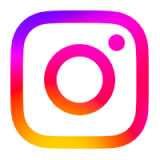
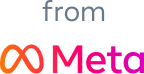

In [68]:
# 그럼 재개는?
# 같은 config값으로 사용해줘야함
args = {
    'input': None,
    'config': config
}
print_update(graph_with_memory, args)

In [69]:
# 이제 다음 노드가 뭔지 보자
snapshot = graph_with_memory.get_state(config)

snapshot.next

()

# interrupt 실제 사용 예시

툴을 이용해서 결과들을 가져왔는데 임의로 내가 작성한 내용으로 바꿔치기 하고 툴이 가져온것처럼 할것임.

In [ ]:
# 메모리 초기화 해주고
memory = MemorySaver()
graph_with_memory = graph_builder.compile(memory)


In [94]:
# 똑같이 tools에서 멈추기

input = State(messages=[('user', '대전 맛집 5개!')])
args = {
    'input': input,
    'config': config,
    'interrupt_before': ['tools']
}

print_update(graph_with_memory, args)


[chatbot]

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 99, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b541469465', 'id': 'chatcmpl-DfnNTtcAwokGw8N3PymGtApnWyJQd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2bf0-4680-78c2-aebf-cff2eec7607f-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '대전 맛집 추천'}, 'id': 'call_TXUx7glCDvDQVakFonDGpzzS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 99, 'output_tokens': 21, 'total_tokens': 120, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio'

In [95]:
changed_message = (
    '바뀐 내용..! 관평도 노랑물고기, 대전 성심당, 대전역 시골집..? 이었나 노은동 진미오겹살!'
)

In [96]:
# snapshot을 가지고 와서 ID를 이용해서 바꾼다.
snapshot = graph_with_memory.get_state(config)
message = snapshot.values['messages'][-1]

new_message = ToolMessage(
    content=changed_message,
    tool_call_id=message.tool_calls[0]['id']
)

# 그리고 update_state로 바꾼다.
new_output = graph_with_memory.update_state(config,
                                {'messages': [new_message]},
                                as_node='tools' # 툴이 준것처럼 거짓말 치기
                                )
new_output

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f150667-bb4d-64b0-8002-a34470d36acb'}}

In [ ]:

snapshot = graph_with_memory.get_state(config)
snapshot.values['messages']

[HumanMessage(content='대전 맛집 5개!', additional_kwargs={}, response_metadata={}, id='84d8858f-cf5a-42a7-b9e8-9388e235fedf'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 99, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b541469465', 'id': 'chatcmpl-DfnNTtcAwokGw8N3PymGtApnWyJQd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2bf0-4680-78c2-aebf-cff2eec7607f-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '대전 맛집 추천'}, 'id': 'call_TXUx7glCDvDQVakFonDGpzzS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 99, 'output_tokens': 21, 'total_to

In [98]:
# 그럼 재개해보자
args = {
    'input': None,
    'config': config
}
print_update(graph_with_memory, args)


[chatbot]

{'messages': [AIMessage(content='대전에서 추천하는 맛집 5곳은 다음과 같습니다:\n\n1. **관평도 노랑물고기** - 신선한 해산물 요리를 즐길 수 있는 곳입니다.\n2. **대전 성심당** - 유명한 빵집으로, 다양한 빵과 디저트를 제공합니다.\n3. **대전역 시골집** - 전통적인 한식을 맛볼 수 있는 곳으로, 푸짐한 한상이 특징입니다.\n4. **노은동 진미오겹살** - 맛있는 오겹살을 전문으로 하는 고기집입니다.\n5. **(추가 추천)** - 대전의 다른 인기 맛집들도 많으니, 다양한 음식을 시도해보세요!\n\n각 맛집의 위치와 메뉴를 확인하고 방문해 보세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 176, 'prompt_tokens': 171, 'total_tokens': 347, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b541469465', 'id': 'chatcmpl-DfnOotDpNPJSsRvcY0emFY1o43iLo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2bf1-8a75-7d23-bfb7-309f54ec8a7d-0', tool_calls=[], invali

# 중간 개입을 실제 사람의 입력으로

interrupt before를 보면서 당연히 든 생각.
중간에 사람의 도움이 필요할 때 멈추게 하겠구나.
그걸 비슷하게 구현해볼것임.

여기서 tool을 정의하는 다른 방식을 경험.

In [142]:
from pydantic import BaseModel
# 사람 불러오기 용 tool을 class로 설정
class HumanCall(BaseModel):
    """Forward the conversation to an expert or person. Use when you can't assist directly or the user needs assistance that exceeds your authority.
    To use this function, pass the user's 'request' so that an expert can provide appropriate guidance.
    """
    request: str



In [158]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage

# 툴들 추가
tavily_tool = TavilySearch(max_results=3)
tools = [tavily_tool, HumanCall]

# 그래프 만들기
# 상태부터
class State(TypedDict):
    messages: Annotated[list, add_messages]
    ask_human: bool

llm_with_tools = llm.bind_tools(tools)

# chatbot node
def chatbot(state):
    messages = [
        SystemMessage(
            content=(
                "If you need additional user preferences or clarification, "
                "you MUST use the HumanCall tool instead of asking directly."
            )
        )
    ] + state['messages']
    response = llm_with_tools.invoke(messages)

    # 초기에는 False로 고정
    ask_human = False

    # llm이 사람이 필요하다고 했는지 보자
    if response.tool_calls and response.tool_calls[0]['name'] == HumanCall.__name__:
        ask_human = True

    return {'messages': [response],
            'ask_human': ask_human}

# tool이 대답한것처럼 보여야 하므로 설정
def create_response(response:str, ai_message):
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]['id']
    )

# human node
def human(state):
    ai_message = state['messages'][-1]
    user_messages = []
    while(not user_messages):
        try:
            user_input = input(f"사람의 도움이 필요합니다. 초기 질문은 {state['messages'][0].content}입니다. 기회는 1번!")
            user_messages.append(create_response(
                user_input, ai_message
            ))
        except Exception as e:
            print(type(e))
            print(e)
            user_messages.append(create_response(
                response='No response from human or error', ai_message=ai_message
            ))
    
    return {'messages': user_messages,
            # 해제
            'ask_human': False}

graph_builder = StateGraph(State)
graph_builder.add_node(chatbot)
graph_builder.add_node('tools', ToolNode([tavily_tool]))
graph_builder.add_node(human)

In [159]:
# human으로 갈지 tool로 갈지 end로 갈지 라우터 생성
def select_next_node(state):
    ask_human = state['ask_human']
    if ask_human:
        return 'human'
    return tools_condition(state)

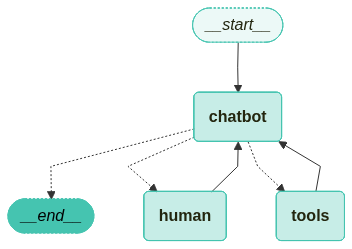

In [160]:
# 마무리
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges(
    'chatbot',
    select_next_node,
    {
        'human': 'human',
        'tools': 'tools',
        END: END
    }
)
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge('human', 'chatbot')
graph = graph_builder.compile(MemorySaver())
visualize_graph(graph)


[chatbot]

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 16145, 'total_tokens': 16181, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 16000}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33abf44359', 'id': 'chatcmpl-Dg4EIK2opt4ZjTzVYeEg9etaiSwp7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2fcc-ba9f-79c1-97cc-996ff84def88-0', tool_calls=[{'name': 'HumanCall', 'args': {'request': '대전 맛집 추천을 원하시는 분의 취향에 맞춰서 정보를 제공해 주세요.'}, 'id': 'call_zFeWKHnStxWZs9DnCxTdlbZf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 16145, 'output_tokens': 36, 'total_tokens': 16181, 'input_token_details': {'audio': 0, 'cache_read'
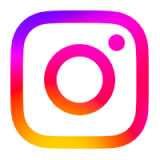
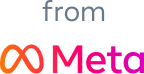

In [ ]:
# input은 내장함수인데 종종 변수로 쓰는 경우가 있음
# 이름 탐색 순서가 local -> global -> builtins로 마지막에 사용됨
# 모르고 위에서 썼어서 변수를 초기화 하고 싶으면 del input을 쓰면됨.
config = RunnableConfig(recursion_limit=10,
                        configurable={'thread_id': '1'})
inputs = State(messages=[('user', '대전 맛집을 추천해주세요. 제 취향에 맞춰서 알려주시길 바랍니다.')])
args = {
    'input': inputs,
    'config': config
}
print_update(graph, args)

## 메세지를 삭제

추후에 cost나 latency문제로 메세지를 줄이고 싶을 것이다.
그때를 위해서 메세지 삭제 노드를 추가해보자

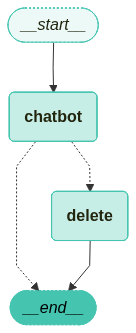

In [163]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, RemoveMessage

# 상태 정의부터 그래프 만들기 까지
# 아래의 거를 MessagesState 함수로
# class State(TypedDict):
#     messages: Annotated[list, add_messages]

def chatbot(state):
    response = llm.invoke(state['messages'])
    return {'messages': [response]}

# 메세지 삭제 노드
def delete(state):
    messages = state['messages']
    # 메세지 마지막 3개만 보존하는 함수
    delete_messages = [RemoveMessage(m.id) for m in messages[:-3]]
    return {'messages': delete_messages}

# 툴없이 메세지 삭제만 보자
# 라우터
def should_delete(state):
    messages = state['messages']
    
    # 메세지가 6개가 넘어가면 삭제하자
    if len(messages) > 6:
        return 'delete'
    return END

graph_builder = StateGraph(MessagesState)
graph_builder.add_node(chatbot)
graph_builder.add_node(delete)

graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges(
    'chatbot',
    should_delete,
    {'delete': 'delete', END: END}
)
graph_builder.add_edge('delete', END)

graph = graph_builder.compile(MemorySaver())

visualize_graph(graph)

In [165]:
inputs_1 = MessagesState(messages=[('user', '안녕하세요')])
inputs_2 = MessagesState(messages=[('user', '반가워요')])
inputs_3 = MessagesState(messages=[('user', '잘있어요')])

args_1 = {
    'input': inputs_1,
    'config': config
}
args_2 = {
    'input': inputs_2,
    'config': config
}
args_3 = {
    'input': inputs_3,
    'config': config
}
print_update(graph, args_1)
print_update(graph, args_2)
print_update(graph, args_3)



[chatbot]

{'messages': [AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fbf6c0be0a', 'id': 'chatcmpl-Dg4Ono9PSfWi5OtEZMLWWMTCKePIo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2fd6-a961-7860-b826-9d37c7f43c99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

[chatbot]

{'messages': [AIMessage(content='저도 반가워요! 어떤 이야기를 나누고 싶으신가요?', additional_k

In [167]:
# 메세지 잘 저장됐는지 보자
snapshot = graph.get_state(config)

messages = snapshot.values['messages']
messages

[HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='4a7f4d6a-420f-474a-a054-9aba3be5c07c'),
 AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fbf6c0be0a', 'id': 'chatcmpl-Dg4Ono9PSfWi5OtEZMLWWMTCKePIo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2fd6-a961-7860-b826-9d37c7f43c99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [168]:
# 하나 더 추가
inputs_4 = MessagesState(messages=[('user', '하나 더 해볼까요?')])

args_4 = {
    'input': inputs_4,
    'config': config
}
print_update(graph, args_4)


[chatbot]

{'messages': [AIMessage(content='물론이죠! 어떤 주제로 이야기해볼까요? 질문이나 주제가 있다면 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 96, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_26d83d7ac6', 'id': 'chatcmpl-Dg4Q2mPTvIDfdHU2gWOeKcxHLJFLM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2fd7-d4ea-7b70-8f59-9151d6d4bd86-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 23, 'total_tokens': 119, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

[delete]

{'messages': [RemoveMessage(content='', additio

In [169]:
# 메세지 다시 보자
snapshot = graph.get_state(config)

messages = snapshot.values['messages']
messages

[AIMessage(content='네, 잘 지내고 있어요! 당신은 어떻게 지내고 계신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 61, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_26d83d7ac6', 'id': 'chatcmpl-Dg4Opl1sCnV9aCvmFg6d7jyCD2qpY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2fd6-b191-7542-be5a-24e9fd095268-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 61, 'output_tokens': 20, 'total_tokens': 81, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 HumanMessage(content='하나 더 해볼까요?', additional_kwargs={}, response_metadata={}, id='6f23daad-5d9c-

## ToolNode 따로 이용

ToolNode를 만들어서 llm에 연결시켜서 이용했는데
따로 이용한다면 어떤 느낌인지 살펴보자

In [172]:
from langchain_teddynote.tools import GoogleNews
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langchain_core.tools import tool

# google news 검색용 툴 정의
@tool
def search(query):
    """Search Google News by input query"""
    news_tool = GoogleNews()
    return news_tool.search_by_keyword(query, k=5)

# python code를 실행해주는 툴 정의
@tool
def execute_python_code(query):
    """Use this to execute python code."""
    return PythonAstREPLTool().invoke({'query': query})

In [ ]:
from langchain_core.messages import AIMessage
from langgraph.runtime import Runtime

# 툴들을 정의
tools = [search, execute_python_code]
tool_node = ToolNode(tools)

# 직접 내용을 수동으로 채운 AIMessage를 생성
# search tool만 사용
search_message = AIMessage(
    content='',
    tool_calls=[
        {
            'name': 'search',
            'args': {'query': 'AI'},
            'id': 'tool_call_id',
            'type': 'tool_call'
        }
    ]
)

"""
- 아래 실행시 참고
tool_node따로 실행하면 내부가 필요로 하는 인자값들이 몇몇 존재하는데
Runtime()은 이를 구조적으로 만들어줌.
즉, 실제 값은 여기서 설정하지 않았지만 구조 자체를 만들어줘서 실행이 됨
"""
# search_tool 사용해보기
tool_node.invoke({'messages': [search_message]},
                 runtime=Runtime())



{'messages': [ToolMessage(content='[{"url": "https://news.google.com/rss/articles/CBMiVkFVX3lxTE42NE1HbHFraWJCUHdiaVRTYnVDQV9DaW13QjE4aUt1YzdGLXVjczhMLTE2RjVVNEppMjB5cWVzZXRZYWxjaTA1VTNxVk9qVmR0NC1yUW93?oc=5", "content": "목사도 농부도 음악가도 뒤집혔다…美 전역 꿈틀대는 ‘AI 반란’ - 중앙일보"}, {"url": "https://news.google.com/rss/articles/CBMiakFVX3lxTE1uZnJ1TldHMlJhbjB4eWFGbXpDQ1VCNGN3c0Y2V3B6ZEVZRk1kQ0JKdXFNajVLU1ZSdFF5cmctd2Zha24yeEZHaU9oa2RzdnFQNnY4ZlhPQUt1TThTODFRRVBHYWxmMXpVSHc?oc=5", "content": "넷플릭스, \'AI 애니메이션\' 직접 만든다…전문 스튜디오 설립 - AI타임스"}, {"url": "https://news.google.com/rss/articles/CBMiYEFVX3lxTE9CQlZJb1Yzc0NKWHBjRE1ZaE5IcnF5eVNUQTdoZEVKclBlY0s1cVVacXR4WVlsbXhyZV9nZmVfSWxmc2xOSHo3czJvRFFIcGdvVnYxN0JxanhTQjB5VWYyZNIBeEFVX3lxTE1SQmYzRDJYZmQxSUU3eHhvSm92UnB5VzJzVF9MQ1VsX1hOZ2xNZDlORk0zMS1wZGdFbXdTMHlGallkZDJ3X2s3NGlZbWJUZExQNGFDYWJ3bFpqc2pXTlFIcU1QWjlpQVFsQjdCeTV5M1ZBcXJ1Z2Y0SA?oc=5", "content": "올해 신설학과 3471개…인공지능 시대 \'AI·융합\' 주목 - 뉴시스"}, {"url": "https://news.google.com/rss/articles/CBMiZEFVX3lxTE9tY

In [181]:
# 이제 둘다 써보자
two_tool_message = AIMessage(
    content='',
    tool_calls=[
        {
            'name': 'search',
            'args': {'query': 'AI'},
            'id': 'tool_call_id',
            'type': 'tool_call'
        },
        {
            'name': 'execute_python_code',
            'args': {'query': "print(1+2+3+4+5)"},
            'id': 'tool_call_id',
            'type': 'tool_call'
        }
    ]
)

tool_node.invoke({'messages': [two_tool_message]},
                 runtime=Runtime())

{'messages': [ToolMessage(content='[{"url": "https://news.google.com/rss/articles/CBMiVkFVX3lxTE42NE1HbHFraWJCUHdiaVRTYnVDQV9DaW13QjE4aUt1YzdGLXVjczhMLTE2RjVVNEppMjB5cWVzZXRZYWxjaTA1VTNxVk9qVmR0NC1yUW93?oc=5", "content": "목사도 농부도 음악가도 뒤집혔다…美 전역 꿈틀대는 ‘AI 반란’ - 중앙일보"}, {"url": "https://news.google.com/rss/articles/CBMiW0FVX3lxTE4yOUdLeWlZRmJQNWJHQlZpR05QU3haWVIxOWxjMnRCT3ZabHdrQTNkclhsZ29zWlhrMDdpWHh6ZTFZRTBVSTMza052UmVZblI2NmppNDQ2MHFGenfSAWBBVV95cUxNUzhOZERHNFR6WWt3Y0lxaE41OTZaWEQ3dy0tems1MjVFcktNM1lRTEZWLVZGVHFLSE5ESVFxRVZIalQ5RjNHc0c0c2kzUHBtU3Rndy1LU1QwQjBwTmNWbDM?oc=5", "content": "북한 해커 손에 들어간 AI…사이버 공격 자동화 현실화 - 연합뉴스"}, {"url": "https://news.google.com/rss/articles/CBMiakFVX3lxTE1FVDQxMGpYMXVudTRSb2N0UWllV3dTcklBMzRabncwUS1KYTNFYWItSGJhVGFMMkp6WDNWdXphT09GdWQ1WWU2V3NnN0MwSlp0U2VkSzNyQXpncTVXZ29hZEVJZHdhYWJvdGc?oc=5", "content": "\'미소스\' 최신 버전, AI 해킹 역량 \\"4.7개월마다 2배 성장\\"마저 추월 - AI타임스"}, {"url": "https://news.google.com/rss/articles/CBMiT0FVX3lxTE53YWhuaFQ5U0Fwa3ZKRVhYUHlPU1Rwalh

In [195]:
# llm에 연결하면 이느낌
llm_with_tools = llm.bind_tools(tools)
response = llm_with_tools.invoke('AI 최신 뉴스')
response

c:\kimjiwan\langgraph_study\.venv\Lib\site-packages\langchain_community\cache.py:272: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(row[0]) for row in rows]


AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 68, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8f0dac2a97', 'id': 'chatcmpl-DgJgyf5w532XzGjpZYGAku9TxtmWE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3357-a816-79e1-bc8c-5ca6cf9dd0ca-0', tool_calls=[{'name': 'search', 'args': {'query': 'AI 최신 뉴스'}, 'id': 'call_OkQ5TF3LZgibovDRfL11f1za', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 15, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}, 'total_cost': 0})

In [196]:
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  search (call_OkQ5TF3LZgibovDRfL11f1za)
 Call ID: call_OkQ5TF3LZgibovDRfL11f1za
  Args:
    query: AI 최신 뉴스


In [ ]:
# 완전 수동으로 까지는 아니지만 이제 위의 메세지를 넣으면 되겠지?
tool_response = tool_node.invoke({'messages': [response]},
                 runtime=Runtime())
tool_response

{'messages': [ToolMessage(content='[{"url": "https://news.google.com/rss/articles/CBMiakFVX3lxTE1FVDQxMGpYMXVudTRSb2N0UWllV3dTcklBMzRabncwUS1KYTNFYWItSGJhVGFMMkp6WDNWdXphT09GdWQ1WWU2V3NnN0MwSlp0U2VkSzNyQXpncTVXZ29hZEVJZHdhYWJvdGc?oc=5", "content": "\'미소스\' 최신 버전, AI 해킹 역량 \\"4.7개월마다 2배 성장\\"마저 추월 - AI타임스"}, {"url": "https://news.google.com/rss/articles/CBMiW0FVX3lxTE9QaFZNTVlpZDhuTEdnR2xULWdTSVpiLVdUUjhYdU5CSGZWTW1IQlhodUNUTlNndWRVMm5TelYxNkM2cGktUC0ybzNheTh5VVhaRFZGVVVXU0J4TEXSAWBBVV95cUxOaHNBdFZicGZueEdiTVNocXBwQ3cybWlQbnFoZlZBU0JibTRNRU1yWlV6T3d0eXZxNlFYM2hfMVd4TWQtZmdxRGJyMmpnb3g5dlRxRlRQTFZCa3RTQnd0WkI?oc=5", "content": "[테크톡노트] AI 많이 쓸수록 돈 샌다…\'토크노믹스\' 비상 - 연합뉴스"}, {"url": "https://news.google.com/rss/articles/CBMiVkFVX3lxTFBLcjhTNXdXXzB5TTlOXzZNNjA3d2hRLWxaZk9ZMzI3N2xRcExobXROSG40aEd1bGVrazNQVG1EZzdXZHozTHU5V0xhQk1UbTBTRmVzRWJR?oc=5", "content": "\\"AI는 도구가 아니라 R&D 혁신 행위자\\"...기경학회, 서울서 국제학회 - 지디넷코리아"}, {"url": "https://news.google.com/rss/articles/CBMiZ0FVX3lxTFAwT25GOUtqNVVucG

In [ ]:
# 이걸 llm에 연결하면 여태 공부했던 state, chatbot, graph_builder 구조가 됨.

## 병렬 노드 실행을 위한 분기

a,b,c,d라는 노드가 있을때 \
a -> b, b -> d \
a -> c, c -> d \
이런 병렬 구조가 있을 수 있다. \
a에서 b,c로 가는걸 fan-out \
b,c에서 d로 가는걸 fan-in \
이라고 한다. \
이렇게 병렬로 처리하는 방식을 해보자

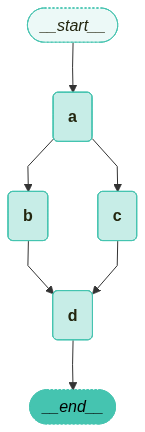

In [200]:
import operator
# 상태 정의 부터
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

# 간단히 하기 위해 llm을 사용하지 않고 특정 값을 내보내는 클래스 정의
class ReturnNodeValue:
    def __init__(self, input):
        self._value = input

    def __call__(self, state):
        print(f"Adding {self._value} from {state['aggregate']}")
        return {'aggregate': [self._value]}
    
builder = StateGraph(State)
builder.add_node('a', ReturnNodeValue("i'm a"))
builder.add_node('b', ReturnNodeValue("i'm b"))
builder.add_node('c', ReturnNodeValue("i'm c"))
builder.add_node('d', ReturnNodeValue("i'm d"))

builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('b', 'd')
builder.add_edge('c', 'd')
builder.add_edge('d', END)

graph = builder.compile()

visualize_graph(graph)


In [201]:
# 실행해보자
graph.invoke({'aggregate': []})

Adding i'm a from []
Adding i'm b from ["i'm a"]
Adding i'm c from ["i'm a"]
Adding i'm d from ["i'm a", "i'm b", "i'm c"]


{'aggregate': ["i'm a", "i'm b", "i'm c", "i'm d"]}

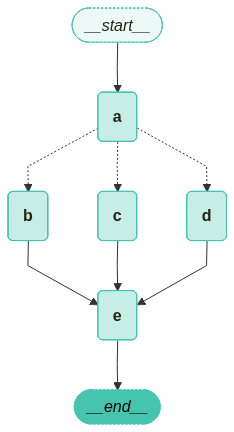

In [204]:
# 위에 처럼 하면 무작정 다 돌게 됨.
# 특정 값들만, 그리고 순서를 정해서 만들수 있음.

# add_message와 유사하지만 합치는 함수를 구현
def reduce_values(left, right):
    if left is None:
        left = []
    if not right:
        return []
    return left + right

class State(TypedDict):
    aggregate: Annotated[list, add_messages]
    fanout_values: Annotated[list, reduce_values]
    next: str

# 위의 값들을 반환할 class 정의
class ParallelNodeValue:
    def __init__(self, node_input, score):
        self._value = node_input
        self._score = score
    
    def __call__(self, state):
        return {'fanout_values':[
            {
                'value': [self._value],
                'score': self._score
            }
        ]}
    
# score 기반으로 합쳐주는 노드용 함수
def rank_value(state):
    ranked_values = sorted(
        state['fanout_values'], key=lambda x: x['score'], reverse=True
    )
    print(ranked_values)
    return {'aggregate': [x['value'][0] for x in ranked_values],
            'fanout_values': []}

# 노드 선택용 라우터
def select_next_node(state):
    if state['next'] == 'bc':
        return ['b', 'c']
    return ['c', 'd']

# 그래프 생성
builder = StateGraph(State)
builder.add_node('a', ReturnNodeValue("i'm a"))
builder.add_node('b', ParallelNodeValue("i'm b", score=0.9))
builder.add_node('c', ParallelNodeValue("i'm c", score=0.2))
builder.add_node('d', ParallelNodeValue("i'm d", score=0.7))
builder.add_node('e', rank_value)

builder.add_edge(START, 'a')
intermediates = ['b', 'c', 'd']

builder.add_conditional_edges(
    'a',
    select_next_node,
    intermediates
)
for node in intermediates:
    builder.add_edge(node, 'e')

builder.add_edge('e', END)

graph = builder.compile()

visualize_graph(graph)

In [205]:
graph.invoke({'aggregate': [], 'fanout_values': [], 'next': 'bc'})

Adding i'm a from []
[{'value': ["i'm b"], 'score': 0.9}, {'value': ["i'm c"], 'score': 0.2}]


{'aggregate': [HumanMessage(content="i'm a", additional_kwargs={}, response_metadata={}, id='eb07ed98-7b6a-44f0-b6ee-3c8ca49b6f11'),
  HumanMessage(content="i'm b", additional_kwargs={}, response_metadata={}, id='3fa24e41-8917-4fe8-bf6e-726ae58df4b1'),
  HumanMessage(content="i'm c", additional_kwargs={}, response_metadata={}, id='6f89be1e-4eec-4ec8-975e-e58251a35a3a')],
 'fanout_values': [],
 'next': 'bc'}

In [206]:
graph.invoke({'aggregate': [], 'fanout_values': [], 'next': 'cd'})

Adding i'm a from []
[{'value': ["i'm d"], 'score': 0.7}, {'value': ["i'm c"], 'score': 0.2}]


{'aggregate': [HumanMessage(content="i'm a", additional_kwargs={}, response_metadata={}, id='cc44ce39-07de-45c1-901d-39bfb6d03e41'),
  HumanMessage(content="i'm d", additional_kwargs={}, response_metadata={}, id='a73f69df-3a26-49b6-bee4-b858cf163eda'),
  HumanMessage(content="i'm c", additional_kwargs={}, response_metadata={}, id='b47e606a-d4f6-40d4-b0c6-f1332567c379')],
 'fanout_values': [],
 'next': 'cd'}

## 대화 요약 생성

위에서 대화 삭제 노드를 추가했었는데 \
이번엔 대화 요약 + 대화 삭제 노드를 추가해 볼것임.

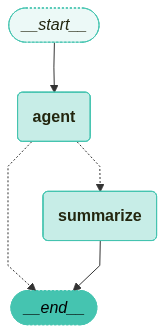

In [211]:
from typing import Sequence
# 상태 정의
class State(TypedDict):
    messages: Annotated[Sequence, add_messages]
    summary: str

# chatbot 부분
def ask_llm(state):
    summary = state.get('summary', '')

    # 요약이 있으면 같이 llm에 넣어주기
    if summary:
        summary_message = f"There is summary of conversation earlier:{summary}"
        messages = [SystemMessage(summary_message)] + state['messages']
    else:
        messages = state['messages']
    
    response = llm.invoke(messages)
    return {'messages': [response]}

# 메세지 삭제 및 요약 노드
def summarize_conversation(state):
    summary = state.get('summary', '')

    # 요약메세지를 생성해서 마지막에 넣어주어야 함.
    # 기존 요약이 있으면 포함하라고 알려줄것.
    if summary:
        summary_message = (
            f"This is summary of the conversation earlier:{summary}\n"
            "Extend the summary by taking into account the new messages above"
            "You should Answer in Korean:"
        )
        
    else:
        summary_message = "Create a summary of the conversation given in Korean:"
    messages =  state['messages'] + [SystemMessage(summary_message)]
    response = llm.invoke(messages)

    # 기존의 메세지들은 요약했으니 어느정도 삭제 (3개만 남기자)
    delete_messages = [RemoveMessage(m.id) for m in messages[:-3]]
    return {'summary': response.content,
            'messages': delete_messages}

# router 부분
def should_delete(state):
    messages = state['messages']
    if len(messages) > 6:
        return 'summarize'
    return END

# 그래프 생성
builder = StateGraph(State)

builder.add_node('agent', ask_llm)
builder.add_node('summarize', summarize_conversation)

builder.add_edge(START, 'agent')
builder.add_conditional_edges(
    'agent',
    should_delete,
    {'summarize': 'summarize', END: END}
)
builder.add_edge('summarize', END)

graph = builder.compile(MemorySaver())

visualize_graph(graph)

In [212]:
# 실행
config = RunnableConfig(
    recursion_limit=10,
    configurable={'thread_id': '1'}
)

inputs = State(messages=[('user', '안녕?')])

In [215]:
# 3번 실행해서 답변까지 총 6개로 만들어보자
args = {
    'config': config,
    'input': inputs
}
print_update(graph, args)


[agent]

{'messages': [AIMessage(content='안녕하세요! 또 뵙네요. 어떻게 지내고 계신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 61, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bf1f66ac25', 'id': 'chatcmpl-DgLFSwkWePXIwJR3uv8sndOcg7XPv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e33b2-f2e2-7f90-a42d-6a6e6e8fe905-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 61, 'output_tokens': 18, 'total_tokens': 79, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}


In [216]:
# 메세지 6개인가 보자
snapshot = graph.get_state(config)
msgs = snapshot.values['messages']
msgs

[HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={}, id='a4f3a9e0-ba1b-42c7-8c74-d1d0398e3ab9'),
 AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d2f048fbf1', 'id': 'chatcmpl-DgLFMHERjPyNr59ei5Xfwj8iVW46J', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e33b2-dcc1-7970-9cf9-248cc5d8d25b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [217]:
# 한번더 실행해서 삭제 실행하도록 ㄱㄱ
inputs = State(messages=[('user', '내 이름은 지지 이고 내 직업은 프리랜서야 나는 AI를 공부하고 있어')])
args = {
    'input': inputs,
    'config': config
}
print_update(graph, args)


[agent]

{'messages': [AIMessage(content='안녕하세요, 지지님! 프리랜서로 일하시면서 AI를 공부하고 계시다니 멋지네요. 어떤 분야의 AI에 관심이 있으신가요? 또는 어떤 질문이 있으신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 109, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fbf6c0be0a', 'id': 'chatcmpl-DgLH5yMUMomGdrJyJFmnyTlDJRjAj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e33b4-7dee-77f0-8c7c-08af0f03c5fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 109, 'output_tokens': 49, 'total_tokens': 158, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

[summarize]

{'sum

In [219]:
snapshot = graph.get_state(config)
msgs = snapshot.values
msgs

{'messages': [HumanMessage(content='내 이름은 지지 이고 내 직업은 프리랜서야 나는 AI를 공부하고 있어', additional_kwargs={}, response_metadata={}, id='97abdb2d-6c39-4de6-adc2-c750e4ba049a'),
  AIMessage(content='안녕하세요, 지지님! 프리랜서로 일하시면서 AI를 공부하고 계시다니 멋지네요. 어떤 분야의 AI에 관심이 있으신가요? 또는 어떤 질문이 있으신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 109, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fbf6c0be0a', 'id': 'chatcmpl-DgLH5yMUMomGdrJyJFmnyTlDJRjAj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e33b4-7dee-77f0-8c7c-08af0f03c5fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 109, 'output_tokens': 49, 'total_t

## subgraph 추가 및 사용 방법

graph를 여러개 만들고 각각을 연결할 수 있다. \
경우 1. state마다 키 값이 똑같다. --> 그대로 사용가능 \
경우 2. state마다 키 값이 다르다. --> 따로 사용하는 부분이 있어야 함.

다음 챕터인 subgraph들과 본 graph와의 연결도 같은 맥락이어서 생략.

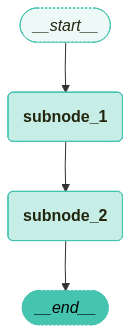

{'name': 'JIJI KI', 'family_name': 'KI'}

In [ ]:
# subgraph 정의
class SubState(TypedDict):
    name: str
    family_name: str

# 굳이 두개로 나눌 필요없는데 초급자 보기 좋게 나눈듯함.
def subnode_1(state):
    return {'family_name': 'KI'}

# 없는키 하나 + 있는키 하나
def subnode_2(state):
    return {'name': f"{state['name']} {state['family_name']}"}

subbuilder = StateGraph(SubState)
subbuilder.add_node(subnode_1)
subbuilder.add_node(subnode_2)

subbuilder.add_edge(START, 'subnode_1')
subbuilder.add_edge('subnode_1', 'subnode_2')
subbuilder.add_edge('subnode_2', END)

subgraph = subbuilder.compile()

visualize_graph(subgraph)

subgraph.invoke({'name': 'JIJI'})


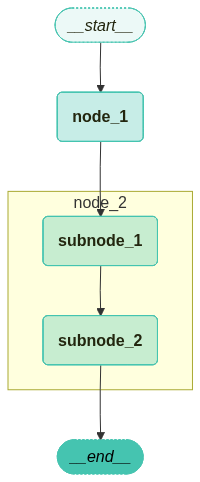

{'name': 'My name is JIJI KI'}

In [222]:
# 본 그래프 생성
class State(TypedDict):
    name: str

def node_1(state):
    return {'name': f"My name is {state['name']}"}

builder = StateGraph(State)
builder.add_node(node_1)
builder.add_node('node_2', subgraph)

builder.add_edge(START, 'node_1')
builder.add_edge('node_1', 'node_2')
builder.add_edge('node_2', END)

graph = builder.compile()

visualize_graph(graph, xray=True)

graph.invoke({'name': 'JIJI'})

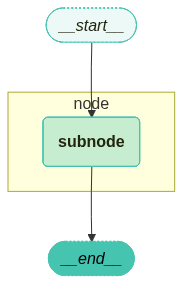

{'full_name': 'My name is JIJI KI'}

In [225]:
# 만약 키 값이 다르다면?
class SubState(TypedDict):
    name: str
    family_name: str

class State(TypedDict):
    full_name: str

def subnode(state):
    return {'name': f"{state['name']} {state['family_name']}"}

subbuilder = StateGraph(SubState)
subbuilder.add_node(subnode)
subbuilder.add_edge(START, 'subnode')
subbuilder.add_edge('subnode', END)

subgraph = subbuilder.compile()

def node(state):
    subgraph_output = subgraph.invoke({'name': state['full_name'],
                                       'family_name': 'KI'})
    name = subgraph_output['name']
    family_name = subgraph_output['family_name']
    return {'full_name': f"My name is {name}"}

builder = StateGraph(State)
builder.add_node(node)
builder.add_edge(START, 'node')
builder.add_edge('node', END)

graph = builder.compile()

visualize_graph(graph, xray=True)

graph.invoke({'full_name': 'JIJI'})